# Eigentime Delay Encoder + JacobianODE — Lorenz (Loop Closure Sweep)

This notebook sweeps over **loop closure weight** values for the JacobianODE
trained using an **eigentime delay adapter** (raw delay embedding + optional PCA)
as the latent space.

**Pipeline:**
1. Set data and ETD hyperparameters directly (no pretrained encoder to load)
2. Build Hydra overrides (single source of truth for both local config and sweep command)
3. Check W&B for already-completed runs
4. Launch Hydra `--multirun` sweep via SLURM (each lambda value = one SLURM job)
5. Collect results from W&B, apply physics-informed model selection (C1/C2/C3)
6. Load the best model for downstream use

**Key idea:** By Takens' theorem, the delay embedding preserves the Lyapunov
spectrum (coordinate-invariant under smooth diffeomorphisms). PCA is a linear
transform and also preserves Lyapunov exponents. Unlike learned encoders, no
dynamical compression occurs.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from omegaconf import OmegaConf
import os
import torch
import wandb

from JacobianODE.jacobians import (
    load_config,
    initialize_config,
    seed_everything,
    make_trajectories,
    postprocess_data,
    create_dataloaders,
    load_run,
    load_checkpoint,
    select_best_model,
    DiagnosticMetrics,
)
from JacobianODE.encoder_only.pretrained import create_eigentime_delay_adapter
from JacobianODE.models.latent_jacobian import LitLatentJacobianODE
from JacobianODE.jacobians.tuning import select_from_wandb_runs
from hydra.utils import instantiate

torch.set_float32_matmul_precision('high')

In [3]:
# ----------------------------------------------------------------
# Paths and W&B settings
# ----------------------------------------------------------------
SAVE_DIR = "/orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning/pretrained_jac_runs"
WANDB_ENTITY = "JacobianODE"
WANDB_PROJECT = "Lorenz_ETD_FULLTEST__JacODE"

# ----------------------------------------------------------------
# Eigentime Delay Adapter settings
# ----------------------------------------------------------------
USE_PCA = True
N_COMPONENTS = 3          # Fixed number of PCA components (set to None to use variance_threshold)
VARIANCE_THRESHOLD = 0.99  # Only used when N_COMPONENTS is None

## 1. Settings

In [4]:
# ----------------------------------------------------------------
# Sweep parameters
# ----------------------------------------------------------------
LAMBDA_LOOP_VALUES = [0, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100]

# ETD is not a learned encoder — always frozen (identity / PCA projection)
FREEZE_ENCODER = True

## 2. Data Hyperparameters

In [5]:
# ----------------------------------------------------------------
# Data hyperparameters (set directly — no pretrained encoder to read from)
# ----------------------------------------------------------------
NUM_ICS = 32
N_PERIODS = 12
PTS_PER_PERIOD = 100
SEQ_LENGTH = 25
# OBS_NOISE = 0.01
OBS_NOISE = 0.0

# OBSERVED_INDICES = [0]     # Observe only x(t)
# N_DELAYS = 5
# DELAY_SPACING = 10

OBSERVED_INDICES = [0, 1, 2]     # Observe only x(t)
N_DELAYS = 1
DELAY_SPACING = 1

print(f"Data config:")
print(f"  NUM_ICS={NUM_ICS}, N_PERIODS={N_PERIODS}, PTS_PER_PERIOD={PTS_PER_PERIOD}")
print(f"  SEQ_LENGTH={SEQ_LENGTH}, OBS_NOISE={OBS_NOISE}")
print(f"  OBSERVED_INDICES={OBSERVED_INDICES}, N_DELAYS={N_DELAYS}, DELAY_SPACING={DELAY_SPACING}")

Data config:
  NUM_ICS=32, N_PERIODS=12, PTS_PER_PERIOD=100
  SEQ_LENGTH=25, OBS_NOISE=0.0
  OBSERVED_INDICES=[0, 1, 2], N_DELAYS=1, DELAY_SPACING=1


In [6]:
# ----------------------------------------------------------------
# Derive N_LATENT from ETD settings
# ----------------------------------------------------------------
# The eigentime delay adapter is built inside each SLURM job from training data.
# Here we just need N_LATENT so we can configure the Jacobian MLP dimensions.
#
# With PCA + fixed n_components: N_LATENT = N_COMPONENTS
# Without PCA: N_LATENT = N_DELAYS (full delay-embedded dimension)

if USE_PCA and N_COMPONENTS is not None:
    N_LATENT = N_COMPONENTS
else:
    # Will be determined at runtime by PCA variance threshold or full dim.
    # For config building, use a placeholder that matches n_delays.
    N_LATENT = N_DELAYS

print(f"Encoder type:    EigentimeDelayAdapter")
print(f"  use_pca:       {USE_PCA}")
print(f"  n_components:  {N_COMPONENTS}")
print(f"  N_LATENT:      {N_LATENT}")
print(f"  Frozen:        {FREEZE_ENCODER} (always — not a learned encoder)")

Encoder type:    EigentimeDelayAdapter
  use_pca:       True
  n_components:  3
  N_LATENT:      3
  Frozen:        True (always — not a learned encoder)


## 3. JacobianODE Hyperparameters (fixed across sweep)

In [7]:
# ----------------------------------------------------------------
# JacobianODE integration
# ----------------------------------------------------------------
# PREDICTION_STEPS = 10
PREDICTION_STEPS = 30
# PREDICTION_STEPS = 50
TRAJ_INIT_STEPS = 15
INTERP_PTS = 4
INNER_N = 20
JAC_WINDOW_STRIDE = PREDICTION_STEPS  # non-overlapping

# ----------------------------------------------------------------
# Jacobian MLP architecture
# ----------------------------------------------------------------
# JAC_HIDDEN_DIM = [256, 512, 512]
# JAC_NUM_LAYERS = 3
JAC_HIDDEN_DIM = [256, 1024, 2048, 2048]
JAC_NUM_LAYERS = 4
JAC_ACTIVATION = 'silu'

# ----------------------------------------------------------------
# Fixed loss weights (loop_closure_weight is swept)
# ----------------------------------------------------------------
RECONSTRUCTION_LOSS_WEIGHT = 0.0 if FREEZE_ENCODER else 1.0
# LATENT_PREDICTION_LOSS_WEIGHT = 0.0
LATENT_PREDICTION_LOSS_WEIGHT = 1.0
JAC_CONSISTENCY_WEIGHT = 0.0
# FNN_WEIGHT = 0.0 if FREEZE_ENCODER else 0.001
FNN_WEIGHT = 0.0

# ----------------------------------------------------------------
# Training
# ----------------------------------------------------------------
BATCH_SIZE = 16
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 200
# LIMIT_TRAIN_BATCHES = 500
LIMIT_TRAIN_BATCHES = 200
LIMIT_VAL_BATCHES = 50
ACCUMULATE_GRAD_BATCHES = 4
EARLY_STOPPING_PATIENCE = 2

## 4. Build Base Config

In [8]:
_hidden_dim_str = str(JAC_HIDDEN_DIM).replace(' ', '')
_obs_idx_str = str(list(OBSERVED_INDICES)).replace(' ', '') if OBSERVED_INDICES != "all" else "all"

# For N_COMPONENTS=None (variance threshold), pass "null" to Hydra
_n_components_str = str(N_COMPONENTS) if N_COMPONENTS is not None else "null"

overrides = [
    # Model template (eigentime delay — no learned encoder architecture)
    "model=latent_eigentime",
    f"model.encoder.n_latent={N_LATENT}",
    f"model.encoder.n_components={_n_components_str}",
    f"model.encoder.variance_threshold={VARIANCE_THRESHOLD}",
    f"model.prediction_steps={PREDICTION_STEPS}",
    f"model.params.hidden_dim={_hidden_dim_str}",
    f"model.params.num_layers={JAC_NUM_LAYERS}",
    f"model.params.activation={JAC_ACTIVATION}",

    # Data
    "data=dysts",
    "data.flow._target_=JacobianODE.dysts_sim.flows.Lorenz",
    f"data.trajectory_params.num_ics={NUM_ICS}",
    f"data.trajectory_params.n_periods={N_PERIODS}",
    f"data.trajectory_params.pts_per_period={PTS_PER_PERIOD}",
    f"data.postprocessing.obs_noise={OBS_NOISE}",
    f"data.train_test_params.seq_length={SEQ_LENGTH}",
    f"data.train_test_params.delay_embedding_params.observed_indices={_obs_idx_str}",
    f"data.train_test_params.delay_embedding_params.n_delays={N_DELAYS}",
    f"data.train_test_params.delay_embedding_params.delay_spacing={DELAY_SPACING}",

    # Eigentime delay encoder (built from data inside each SLURM job)
    "pretrained_encoder.encoder_type=eigentime_delay",
    f"pretrained_encoder.freeze={FREEZE_ENCODER}",
    f"pretrained_encoder.eigentime.use_pca={USE_PCA}",
    f"pretrained_encoder.eigentime.n_components={_n_components_str}",
    f"pretrained_encoder.eigentime.variance_threshold={VARIANCE_THRESHOLD}",

    # Training
    f"training.batch_size={BATCH_SIZE}",
    f"training.logger.save_dir={SAVE_DIR}",
    f"training.lightning.optimizer_kwargs.lr={LEARNING_RATE}",
    f"training.lightning.optimizer_kwargs.weight_decay={WEIGHT_DECAY}",
    f"training.lightning.reconstruction_loss_weight={RECONSTRUCTION_LOSS_WEIGHT}",
    f"training.lightning.latent_prediction_loss_weight={LATENT_PREDICTION_LOSS_WEIGHT}",
    f"training.lightning.jac_consistency_weight={JAC_CONSISTENCY_WEIGHT}",
    f"training.lightning.fnn_weight={FNN_WEIGHT}",
    "training.lightning.alpha_teacher_forcing=1",
    "training.lightning.teacher_forcing_annealing=True",
    "training.lightning.gamma_teacher_forcing=0.999",
    "training.lightning.loop_closure_training=True",
    "training.lightning.trajectory_training=True",
    f"training.lightning.jacobianODEint_kwargs.traj_init_steps={TRAJ_INIT_STEPS}",
    f"training.lightning.jacobianODEint_kwargs.interp_pts={INTERP_PTS}",
    f"training.lightning.jacobianODEint_kwargs.inner_N={INNER_N}",
    "training.lightning.jacobianODEint_kwargs.inner_path=line",
    f"training.trainer_params.max_epochs={MAX_EPOCHS}",
    f"training.trainer_params.limit_train_batches={LIMIT_TRAIN_BATCHES}",
    f"training.trainer_params.limit_val_batches={LIMIT_VAL_BATCHES}",
    f"training.trainer_params.accumulate_grad_batches={ACCUMULATE_GRAD_BATCHES}",
    f"training.early_stopping.early_stopping_patience={EARLY_STOPPING_PATIENCE}",
]

cfg = load_config(config_name="pretrained_config", overrides=overrides)
cfg = initialize_config(cfg)

# Auto-generate project name
data_cls = cfg.data.flow._target_.split('.')[-1]
if WANDB_PROJECT is None:
    WANDB_PROJECT = f"{data_cls}__ETD_JacODE"
WANDB_PROJECT_PATH = f"{WANDB_ENTITY}/{WANDB_PROJECT}"

print(f"W&B project: {WANDB_PROJECT_PATH}")
print(f"Jacobian MLP: input_dim={cfg.model.params.input_dim}, output_dim={cfg.model.params.output_dim}")

W&B project: JacobianODE/Lorenz_ETD__JacODE
Jacobian MLP: input_dim=3, output_dim=9


## 5. Generate Data (once, shared across sweep)

In [9]:
seed_everything(cfg.data.flow.random_state)
eq, sol, dt = make_trajectories(cfg, verbose=True)
print(f"\nFull trajectory shape: {sol['values'].shape}")
print(f"Time step dt = {dt:.4f}")


Full trajectory shape: (32, 1200, 3)
Time step dt = 0.0150


In [10]:
result = postprocess_data(cfg, sol["values"])
values = result.values
mu = result.mu
sigma = result.sigma
noise_scale_factor = result.noise_scale_factor

cfg.data.postprocessing.mu = float(mu)
cfg.data.postprocessing.sigma = float(sigma)
cfg.data.postprocessing.noise_scale_factor = float(noise_scale_factor)

train_dl, val_dl, test_dl, trajs = create_dataloaders(cfg, values, verbose=True, return_full_obs=True)
n_obs = trajs['train_trajs'].sequence.shape[-1]
n_dims = values.shape[-1]

print(f"\nn_obs = {n_obs}, n_dims = {n_dims}")
print(f"sqrt(n_dims) = {np.sqrt(n_dims):.4f} (C2 loop-closure threshold)")

Sequence Indices:   0%|          | 0/1060 [00:00<?, ?it/s]

Train dataset shape: torch.Size([23320, 100, 5])
Validation dataset shape: torch.Size([7420, 100, 5])
Test dataset shape: torch.Size([3180, 100, 5])
Train trajectories dataset shape: torch.Size([22, 1160, 5])
Validation trajectories dataset shape: torch.Size([7, 1160, 5])
Test trajectories dataset shape: torch.Size([3, 1160, 5])

n_obs = 5, n_dims = 3
sqrt(n_dims) = 1.7321 (C2 loop-closure threshold)


## 6. Launch Sweep over `loop_closure_weight`

Uses Hydra `--multirun` with the SLURM launcher to submit one job per lambda
value in parallel. The entry point `run_pretrained_jacobians` detects
`encoder_type=eigentime_delay` and builds the ETD adapter from training data
inside each SLURM job (no pretrained encoder download needed).

The `overrides` list from Section 4 is the **single source of truth** — the
sweep command simply appends the swept parameter (comma-separated lambda values)
and W&B/SLURM settings.

In [11]:
# ----------------------------------------------------------------
# Check which lambda values already have completed runs on W&B
# ----------------------------------------------------------------
api = wandb.Api()
try:
    existing_runs = api.runs(WANDB_PROJECT_PATH)
    print(f"Found {len(existing_runs)} total runs in {WANDB_PROJECT_PATH}")
except Exception as e:
    print(f"Could not query project (may not exist yet): {e}")
    existing_runs = []

already_run = []
remaining_lambdas = []
for lam in LAMBDA_LOOP_VALUES:
    matching = [
        run for run in existing_runs
        if 'training' in run.config
        and 'lightning' in run.config['training']
        and abs(run.config['training']['lightning'].get('loop_closure_weight', -1) - lam) < 1e-10
        and run.state == 'finished'
    ]
    if matching:
        already_run.append(lam)
    else:
        remaining_lambdas.append(lam)

print(f"\nAlready completed: {already_run}")
print(f"Remaining to run:  {remaining_lambdas}")

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/eisenaj/.netrc.


Found 10 total runs in JacobianODE/Lorenz_ETD__JacODE

Already completed: [0, 1e-06, 1e-05, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
Remaining to run:  []


In [12]:
# ----------------------------------------------------------------
# Build the Hydra --multirun sweep command
# ----------------------------------------------------------------
# Reuses `overrides` from Section 4 as the single source of truth.
# Only the three sweep-specific additions differ from the local config:
#   - loop_closure_weight  : the swept parameter (comma-separated for --multirun)
#   - wandb_entity/project : W&B logging target for the training jobs
#   - slurm=default        : SLURM launcher (not needed locally)

if remaining_lambdas:
    lambda_str = ",".join(str(v) for v in remaining_lambdas)

    sweep_overrides = overrides + [
        f"training.lightning.loop_closure_weight={lambda_str}",
        f"wandb_entity={WANDB_ENTITY}",
        f"wandb_project={WANDB_PROJECT}",
        "slurm=default",
    ]

    sweep_cmd = (
        "python -m JacobianODE.jacobians.run_pretrained_jacobians --multirun "
        + " ".join(sweep_overrides)
    )

    print(f"Sweep command ({len(remaining_lambdas)} jobs):")
    print(sweep_cmd)
else:
    sweep_cmd = None
    print("No sweep to launch — all runs already completed.")

No sweep to launch — all runs already completed.


In [13]:
# Launch the sweep (submits SLURM jobs).
import subprocess
if sweep_cmd is not None:
    # !{sweep_cmd}
    subprocess.run(sweep_cmd, shell=True)
else:
    print("No sweep to launch — all runs already completed.")

No sweep to launch — all runs already completed.


## 7. Collect W&B Runs and Model Selection

### 7a. Collect Run IDs

In [14]:
api = wandb.Api()
all_runs = api.runs(WANDB_PROJECT_PATH)
print(f"Found {len(all_runs)} total runs in {WANDB_PROJECT_PATH}")

# Remove crashed/failed runs (pretrained encoder + JacobianODE)
def _is_pretrained_jac_run(run):
    return "pretrained_encoder" in run.config or (
        "model" in run.config and "encoder" in run.config.get("model", {})
    )

crashed_lambdas = []
for run in all_runs:
    if run.state in ("crashed", "failed") and _is_pretrained_jac_run(run):
        lam = run.config.get("training", {}).get("lightning", {}).get("loop_closure_weight")
        print(f"CRASHED: run_id={run.id} (lambda={lam}) — deleting from W&B")
        run.delete()
        if lam is not None:
            crashed_lambdas.append(lam)

if crashed_lambdas:
    needs_rerun = [
        lam for lam in crashed_lambdas
        if not any(
            r for r in all_runs
            if r.state == "finished"
            and _is_pretrained_jac_run(r)
            and abs(r.config.get("training", {}).get("lightning", {}).get("loop_closure_weight", -1) - lam) < 1e-10
        )
    ]
    print(f"\nDeleted {len(crashed_lambdas)} crashed run(s).")
    if needs_rerun:
        print(f"Re-run the sweep to retry lambda={needs_rerun}")
    else:
        print("All crashed lambdas have other finished runs — no re-runs needed.")
else:
    print("No crashed pretrained Jac runs found.")

# Filter to finished runs matching our encoder type
sweep_run_ids = []
sweep_lambdas = []

for run in all_runs:
    if run.state != 'finished':
        continue
    lc_weight = run.config.get('training', {}).get('lightning', {}).get('loop_closure_weight')
    if lc_weight is not None and lc_weight in LAMBDA_LOOP_VALUES:
        sweep_run_ids.append(run.id)
        sweep_lambdas.append(lc_weight)

# Sort by lambda value
sorted_pairs = sorted(zip(sweep_lambdas, sweep_run_ids))
sweep_lambdas = [p[0] for p in sorted_pairs]
sweep_run_ids = [p[1] for p in sorted_pairs]

print(f"\nFound {len(sweep_run_ids)} matching runs:")
for lam, rid in zip(sweep_lambdas, sweep_run_ids):
    print(f"  lambda={lam} -> run_id={rid}")

Found 10 total runs in JacobianODE/Lorenz_ETD__JacODE
No crashed pretrained Jac runs found.

Found 10 matching runs:
  lambda=0 -> run_id=l1y19nyq
  lambda=1e-06 -> run_id=k6relrt4
  lambda=1e-05 -> run_id=usctzwg7
  lambda=0.0001 -> run_id=6rxbc2zz
  lambda=0.001 -> run_id=nzf20srg
  lambda=0.01 -> run_id=veuybk0n
  lambda=0.1 -> run_id=mpgcbhsx
  lambda=1 -> run_id=tjxwykj5
  lambda=10 -> run_id=sgtgg4sq
  lambda=100 -> run_id=rmbhugud


### 7b. Compute Diagnostics and Select Best Model

In [15]:
# Use the tuning module's select_from_wandb_runs for physics-informed selection
# This loads each model, computes C1/C2/C3, and returns the best
# n_batches=20: fewer batches = faster (~5x); increase to 100 for more stable metrics
sweep_result = select_from_wandb_runs(
    run_ids=sweep_run_ids,
    project=WANDB_PROJECT_PATH,
    dt=dt,
    n_dims=n_dims,
    n_batches=20,
    eigenvalue_threshold=0.001,
    use_loop_closure=True,
    lambda_values=sweep_lambdas,
    save_dir=SAVE_DIR,
    verbose=True,
)

result = sweep_result.selection
all_diagnostics = sweep_result.diagnostics

print("\n" + "=" * 60)
print("MODEL SELECTION RESULT")
print("=" * 60)
print(f"Best lambda:    {sweep_lambdas[result.best_index]}")
print(f"Best run ID:    {sweep_run_ids[result.best_index]}")
print(f"Best traj loss: {result.best_metrics.trajectory_val_loss:.6f}")
print(f"\nCriteria applied (after relaxation): {result.criteria_applied}")
print(f"Surviving models: {len(result.surviving_indices)} / {len(all_diagnostics)}")

  run=l1y19nyq: DiagnosticMetrics(one_step_mase=1.8798940241336823, loop_closure_loss=2107.7536376953126, fast_eigenvalue_fraction=0.0, trajectory_val_loss=0.01874638001900166) (from cache, n_batches=20)
  run=k6relrt4: DiagnosticMetrics(one_step_mase=1.8801296651363373, loop_closure_loss=35.2263840675354, fast_eigenvalue_fraction=0.0, trajectory_val_loss=0.018003064580261706) (from cache, n_batches=20)
  run=usctzwg7: DiagnosticMetrics(one_step_mase=1.8807388246059418, loop_closure_loss=7.1658360123634335, fast_eigenvalue_fraction=0.0, trajectory_val_loss=0.018813840090297164) (from cache, n_batches=20)
  run=6rxbc2zz: DiagnosticMetrics(one_step_mase=1.8824022173881532, loop_closure_loss=5.140612828731537, fast_eigenvalue_fraction=0.0, trajectory_val_loss=0.02361540454439819) (from cache, n_batches=20)
  run=nzf20srg: DiagnosticMetrics(one_step_mase=1.888898491859436, loop_closure_loss=0.9785194762051106, fast_eigenvalue_fraction=0.0, trajectory_val_loss=0.047381520923227075) (from ca

### 7c. Visualize Selection

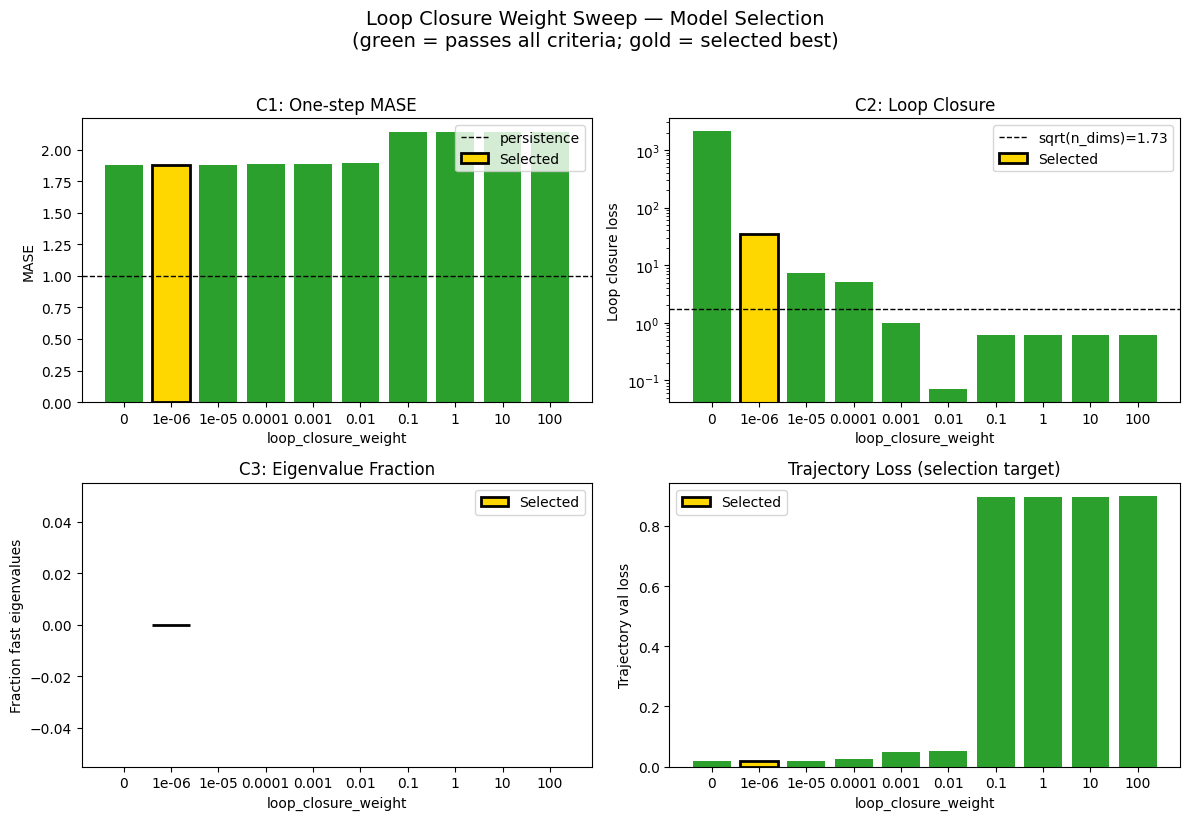

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

one_step_mases = [m.one_step_mase for m in all_diagnostics]
loop_closure_losses = [m.loop_closure_loss for m in all_diagnostics]
eig_fracs = [m.fast_eigenvalue_fraction for m in all_diagnostics]
traj_losses = [m.trajectory_val_loss for m in all_diagnostics]

colors = ['tab:green' if i in result.surviving_indices else 'tab:red'
          for i in range(len(all_diagnostics))]
x_labels = [str(v) for v in sweep_lambdas]
x_pos = range(len(sweep_lambdas))

# Panel 1: One-step MASE
axes[0, 0].bar(x_pos, one_step_mases, color=colors)
if result.best_index is not None:
    axes[0, 0].bar(result.best_index, one_step_mases[result.best_index],
                   color='gold', edgecolor='black', linewidth=2, label='Selected')
axes[0, 0].axhline(y=1.0, color='k', linestyle='--', lw=1, label='persistence')
axes[0, 0].set_xticks(x_pos); axes[0, 0].set_xticklabels(x_labels)
axes[0, 0].set_ylabel('MASE'); axes[0, 0].set_title('C1: One-step MASE')
axes[0, 0].legend()

# Panel 2: Loop closure loss
axes[0, 1].bar(x_pos, loop_closure_losses, color=colors)
if result.best_index is not None:
    axes[0, 1].bar(result.best_index, loop_closure_losses[result.best_index],
                   color='gold', edgecolor='black', linewidth=2, label='Selected')
axes[0, 1].axhline(y=np.sqrt(n_dims), color='k', linestyle='--', lw=1, label=f'sqrt(n_dims)={np.sqrt(n_dims):.2f}')
axes[0, 1].set_xticks(x_pos); axes[0, 1].set_xticklabels(x_labels)
axes[0, 1].set_ylabel('Loop closure loss'); axes[0, 1].set_title('C2: Loop Closure')
axes[0, 1].set_yscale('log')
axes[0, 1].legend()

# Panel 3: Fast eigenvalue fraction
axes[1, 0].bar(x_pos, eig_fracs, color=colors)
if result.best_index is not None:
    axes[1, 0].bar(result.best_index, eig_fracs[result.best_index],
                   color='gold', edgecolor='black', linewidth=2, label='Selected')
axes[1, 0].set_xticks(x_pos); axes[1, 0].set_xticklabels(x_labels)
axes[1, 0].set_ylabel('Fraction fast eigenvalues'); axes[1, 0].set_title('C3: Eigenvalue Fraction')
axes[1, 0].legend()

# Panel 4: Trajectory val loss (selection target)
axes[1, 1].bar(x_pos, traj_losses, color=colors)
if result.best_index is not None:
    axes[1, 1].bar(result.best_index, traj_losses[result.best_index],
                   color='gold', edgecolor='black', linewidth=2, label='Selected')
axes[1, 1].set_xticks(x_pos); axes[1, 1].set_xticklabels(x_labels)
axes[1, 1].set_ylabel('Trajectory val loss'); axes[1, 1].set_title('Trajectory Loss (selection target)')
axes[1, 1].legend()

for ax in axes.flat:
    ax.set_xlabel('loop_closure_weight')

fig.suptitle(
    'Loop Closure Weight Sweep — Model Selection\n'
    '(green = passes all criteria; gold = selected best)',
    fontsize=14, y=1.02,
)
plt.tight_layout()
plt.show()

## 8. Load the Best Model for Downstream Use

In [17]:
best_run_id = sweep_run_ids[result.best_index]
best_lambda = sweep_lambdas[result.best_index]

print(f"Loading best model: run_id={best_run_id}, lambda={best_lambda}")

run, best_cfg, eq, dt, values, _, _, _, _, best_lit_model = load_run(
    WANDB_PROJECT_PATH,
    run_id=best_run_id,
    save_dir=SAVE_DIR,
    generate_data=True,
    verbose=True,
)

# Load trained weights (load_run creates the model architecture but doesn't load checkpoint)
load_checkpoint(run, best_cfg, best_lit_model, save_dir=SAVE_DIR, verbose=True)

# Rebuild dataloaders from the loaded data
train_dl, val_dl, test_dl, trajs = create_dataloaders(best_cfg, values, verbose=True, return_full_obs=True)

print(f"\nModel type: {type(best_lit_model).__name__}")
print(f"Total params: {sum(p.numel() for p in best_lit_model.parameters()):,}")

Loading best model: run_id=k6relrt4, lambda=1e-06
Building eigentime delay adapter (once per sweep)...
EigentimeDelayAdapter: n_obs=5, use_pca=True, n_latent=3
  PCA: 3 components, explained variance = 0.9838
  Singular values: [3383.4404296875, 920.384521484375, 857.7083129882812]
Loading checkpoint epoch=8-step=450.ckpt...


Sequence Indices:   0%|          | 0/1060 [00:00<?, ?it/s]

Train dataset shape: torch.Size([23320, 100, 5])
Validation dataset shape: torch.Size([7420, 100, 5])
Test dataset shape: torch.Size([3180, 100, 5])
Train trajectories dataset shape: torch.Size([22, 1160, 5])
Validation trajectories dataset shape: torch.Size([7, 1160, 5])
Test trajectories dataset shape: torch.Size([3, 1160, 5])

Model type: LitLatentJacobianODE
Total params: 6,578,185


### 8a. Lyapunov Exponent Comparison (Best Model)

Predicted Lyapunov exponents (best model):
  lambda_1 = -0.5736
  lambda_2 = -0.7726
  lambda_3 = -7.6661

True Lorenz:
  lambda_1 = +0.9100
  lambda_2 = +0.0000
  lambda_3 = -14.5700


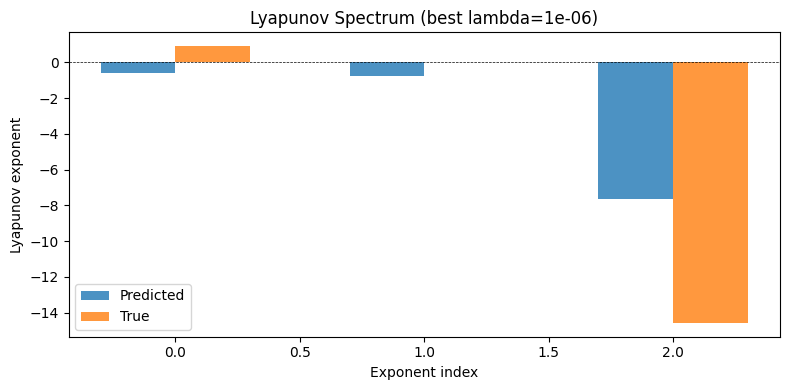

In [18]:
TRUE_LYAPUNOV = [0.91, 0.0, -14.57]

best_lit_model.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"
best_lit_model = best_lit_model.to(device)

with torch.no_grad():
    test_batch = next(iter(test_dl))
    if isinstance(test_batch, (list, tuple)):
        test_batch = test_batch[0]
    test_batch = test_batch.to(device)
    z_test = best_lit_model.encode_trajectory(test_batch)
    z_long = z_test[:5].reshape(-1, z_test.shape[-1]).unsqueeze(0)
    jacs_long = best_lit_model.compute_jacobians(z_long)[0]
    pred_lyap = LitLatentJacobianODE.compute_lyapunov_exponents(jacs_long.cpu(), dt)

print("Predicted Lyapunov exponents (best model):")
for i, le in enumerate(pred_lyap):
    print(f"  lambda_{i+1} = {le.item():+.4f}")
print(f"\nTrue Lorenz:")
for i, le in enumerate(TRUE_LYAPUNOV):
    print(f"  lambda_{i+1} = {le:+.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
pred_np = pred_lyap.numpy()
ax.bar(np.arange(len(pred_np)) - 0.15, pred_np, width=0.3, label="Predicted", alpha=0.8)
ax.bar(np.arange(len(TRUE_LYAPUNOV)) + 0.15, TRUE_LYAPUNOV, width=0.3, label="True", alpha=0.8)
ax.axhline(y=0, color='k', linestyle='--', lw=0.5)
ax.set_xlabel("Exponent index")
ax.set_ylabel("Lyapunov exponent")
ax.set_title(f"Lyapunov Spectrum (best lambda={best_lambda})")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Latent Space Analysis — Participation Ratio & Embeddings

In [19]:
from sklearn.decomposition import PCA
from tqdm.auto import tqdm

best_lit_model.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"
best_lit_model.to(device)

# ---- Encode full trajectories ----
use_train = True  # True = train set, False = test set
traj_key = "train_trajs" if use_train else "test_trajs"
full_obs_key = "train_trajs_full" if use_train else "test_trajs_full"
label_prefix = "Train" if use_train else "Test"

trajs_obs = trajs[traj_key].sequence      # (N_traj, T, D_obs)
trajs_full = trajs[full_obs_key].sequence  # (N_traj, T, D_full)

batch_traj = 8
all_latents = []
with torch.no_grad():
    for i in tqdm(range(0, trajs_obs.shape[0], batch_traj)):
        x = torch.as_tensor(trajs_obs[i : i + batch_traj]).float().to(device)
        z = best_lit_model.encode_trajectory(x)  # (B, T, n_latent)
        all_latents.append(z.cpu())
Z = torch.cat(all_latents, dim=0).numpy()  # (N_traj, T, n_latent)

# Align true state with latent length (encode_trajectory may trim)
T_latent = Z.shape[1]
trajs_full_arr = np.asarray(trajs_full)
X_true = trajs_full_arr[:, -T_latent:, :]  # align from end in case of context margin

Z_flat = Z.reshape(-1, Z.shape[-1])
X_true_flat = X_true.reshape(-1, X_true.shape[-1])

print(f"Latent shape: {Z.shape}")
print(f"True state shape: {X_true.shape}")

  0%|          | 0/3 [00:00<?, ?it/s]

Latent shape: (22, 1160, 3)
True state shape: (22, 1160, 3)


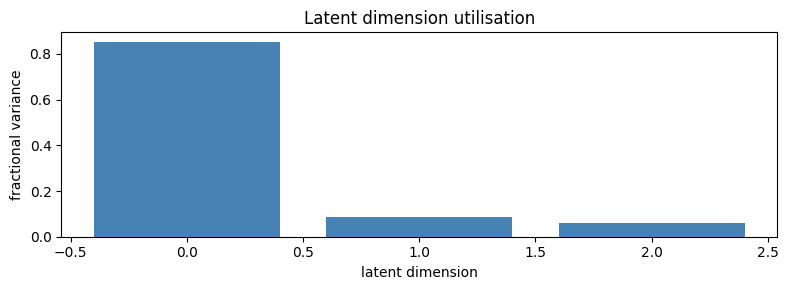

Entropy-based utilization: 0.473  (1.0 = uniform, 0.0 = single dim)


In [20]:
# ---- Per-dimension variance (latent utilisation) ----
import math

dim_var = Z_flat.var(axis=0)

fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(range(len(dim_var)), dim_var / dim_var.sum(), color='steelblue')
ax.set_xlabel('latent dimension')
ax.set_ylabel('fractional variance')
ax.set_title('Latent dimension utilisation')
plt.tight_layout()
plt.show()

p = dim_var / dim_var.sum()
entropy = -np.sum(p * np.log(p + 1e-10))
n_latent = Z_flat.shape[-1]
utilization = entropy / math.log(n_latent)
print(f'Entropy-based utilization: {utilization:.3f}  (1.0 = uniform, 0.0 = single dim)')

Participation ratio — Latents: 1.356  |  True state (Train): 1.499


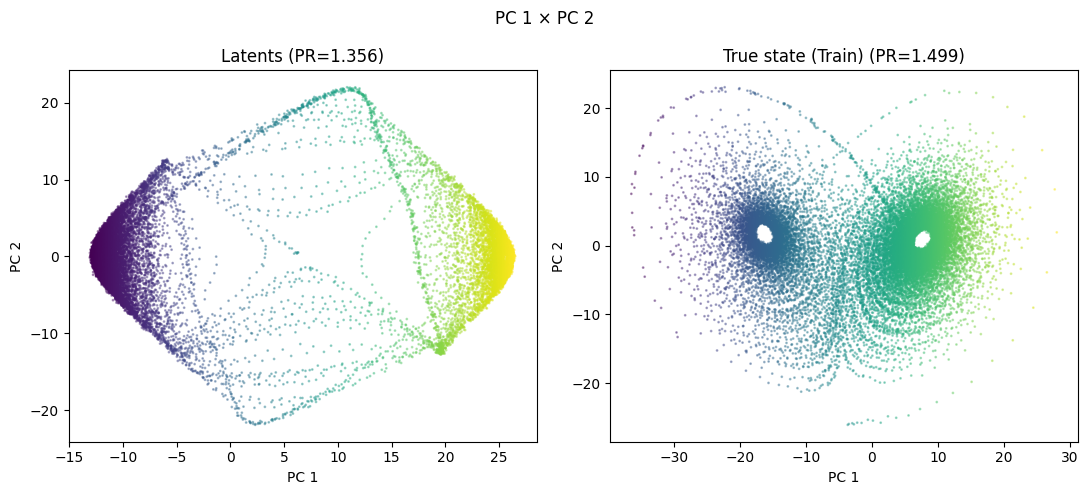

In [21]:
# ---- Participation ratio and PCA embedding plots ----
def participation_ratio(X):
    X_flat = X.reshape(-1, X.shape[-1])
    cov = np.cov(X_flat, rowvar=False)
    eigvals = np.linalg.eigvalsh(cov)
    return (eigvals.sum()) ** 2 / ((eigvals**2).sum() + 1e-12)

pr_latent = participation_ratio(Z_flat)
pr_true = participation_ratio(X_true_flat)
print(f"Participation ratio — Latents: {pr_latent:.3f}  |  True state ({label_prefix}): {pr_true:.3f}")

# PCA for plotting
pca_latent = PCA(n_components=2).fit(Z_flat)
pca_true = PCA(n_components=2).fit(X_true_flat)
Z_pc = pca_latent.transform(Z_flat)
X_true_pc = pca_true.transform(X_true_flat)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].scatter(Z_pc[:, 0], Z_pc[:, 1], s=1, alpha=0.4, c=Z_pc[:, 0], cmap="viridis")
axes[0].set_xlabel("PC 1"); axes[0].set_ylabel("PC 2")
axes[0].set_title(f"Latents (PR={pr_latent:.3f})")
axes[1].scatter(X_true_pc[:, 0], X_true_pc[:, 1], s=1, alpha=0.4, c=X_true_pc[:, 0], cmap="viridis")
axes[1].set_xlabel("PC 1"); axes[1].set_ylabel("PC 2")
axes[1].set_title(f"True state ({label_prefix}) (PR={pr_true:.3f})")
fig.suptitle("PC 1 × PC 2", fontsize=12)
plt.tight_layout()
plt.show()

Normalized FNN loss — True state:  0.041294
Normalized FNN loss — Latents:     0.054782


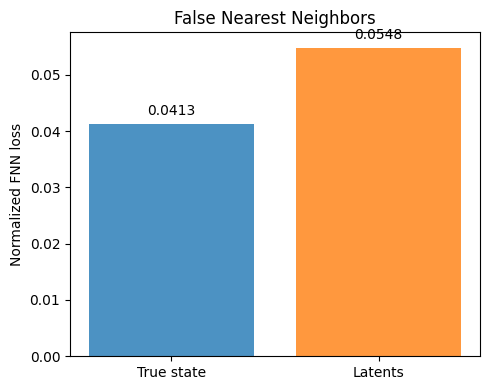

In [22]:
from JacobianODE.fnn import loss_false

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_PCA_PROJECTION = True
USE_NORMALIZE = True
ELEMENTWISE_REGULARIZATION = True

X_true_t = torch.from_numpy(X_true_flat).float().to(DEVICE)
X_latent_t = torch.from_numpy(Z_flat).float().to(DEVICE)

# Subsample for O(N^2) FNN
N_max = 2048
n = min(len(X_true_t), len(X_latent_t))
if n > N_max:
    rng = np.random.default_rng(42)
    idx = rng.choice(n, N_max, replace=False)
    X_true_t = X_true_t[idx]
    X_latent_t = X_latent_t[idx]

if USE_PCA_PROJECTION:
    X_true_np = X_true_t.detach().cpu().numpy()
    X_latent_np = X_latent_t.detach().cpu().numpy()
    pca_t = PCA(n_components=X_true_np.shape[1]).fit(X_true_np)
    pca_l = PCA(n_components=X_latent_np.shape[1]).fit(X_latent_np)
    X_true_t = torch.from_numpy(pca_t.transform(X_true_np)).float().to(DEVICE)
    X_latent_t = torch.from_numpy(pca_l.transform(X_latent_np)).float().to(DEVICE)

with torch.no_grad():
    fnn_true = loss_false(X_true_t, k=1, normalize=USE_NORMALIZE, elementwise_regularization=ELEMENTWISE_REGULARIZATION).item()
    fnn_latent = loss_false(X_latent_t, k=1, normalize=USE_NORMALIZE, elementwise_regularization=ELEMENTWISE_REGULARIZATION).item()

print(f"{'Normalized' if USE_NORMALIZE else 'Unnormalized'} FNN loss — True state:  {fnn_true:.6f}")
print(f"{'Normalized' if USE_NORMALIZE else 'Unnormalized'} FNN loss — Latents:     {fnn_latent:.6f}")

fig, ax = plt.subplots(figsize=(5, 4))
labels = ["True state", "Latents"]
vals = [fnn_true, fnn_latent]
bars = ax.bar(labels, vals, color=["C0", "C1"], alpha=0.8)
ax.set_ylabel("Normalized FNN loss")
ax.set_title("False Nearest Neighbors")
for bar, val in zip(bars, vals):
    ax.annotate(f"{val:.4f}", xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 4), textcoords="offset points", ha="center", va="bottom")
plt.tight_layout()
plt.show()

## 10. Generated Predictions (Latent & Observation Space)

Roll out the model's built-in generation (no teacher forcing) and compare latent + observation predictions to ground truth.

Batch normalized MSE: 0.072699  (diagnostic avg: 0.018003)
Latent window shape:       (45, 3)
Obs prediction shape:      (30, 5)
traj_init_steps=15, prediction_steps=30


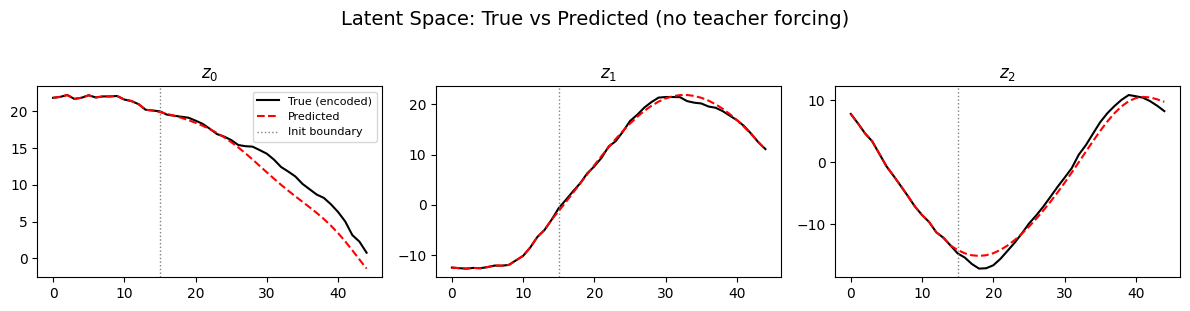

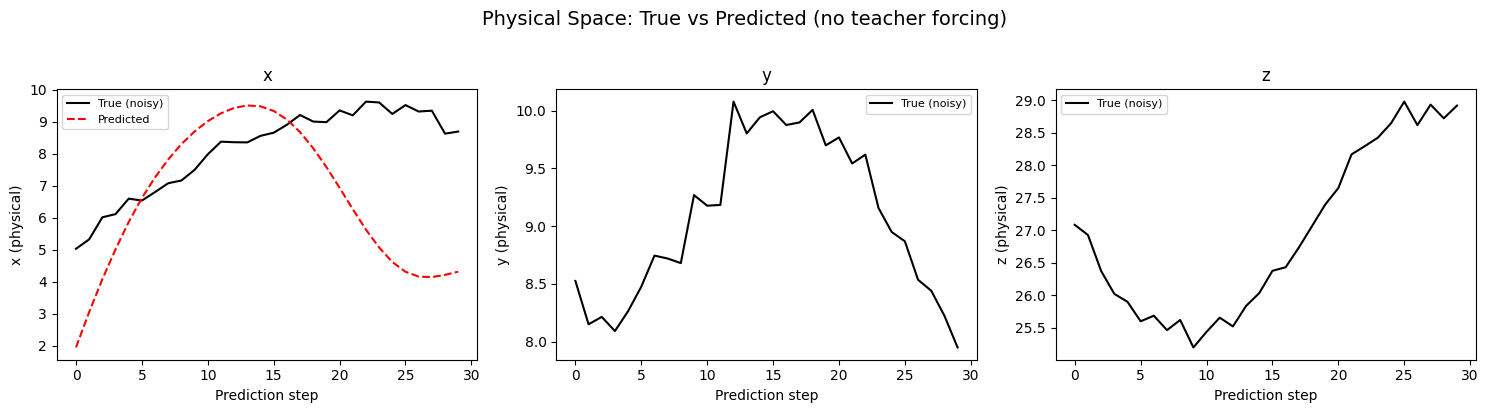

In [23]:
from JacobianODE.jacobians.metrics import normalized_mse as nmse_fn

best_lit_model.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"
best_lit_model = best_lit_model.to(device)

# Use trajectory data (full-length) so we can align with full-state ground truth.
traj_obs = torch.as_tensor(trajs['test_trajs'].sequence[:1]).float().to(device)  # (1, T_emb, 43)

# Run trajectory prediction with NO teacher forcing
with torch.no_grad():
    result_dict = best_lit_model.trajectory_model_step(
        traj_obs,
        alpha_teacher_forcing=0.0,
        obs_noise_scale=0,
        return_decoded=True,
    )

z_pred_full = result_dict['outputs']       # (N, jac_window_len, D_latent)
decoded_pred = result_dict['decoded']       # (N, prediction_steps, D_obs)
obs_targets = result_dict['targets']        # (N, prediction_steps, D_obs)

# Print the actual loss for this batch to compare with diagnostics
batch_nmse = nmse_fn(obs_targets, decoded_pred).item()
print(f"Batch normalized MSE: {batch_nmse:.6f}  (diagnostic avg: {result.best_metrics.trajectory_val_loss:.6f})")

# Also get the true latent trajectory for comparison
with torch.no_grad():
    z_true_full = best_lit_model.encode_trajectory(traj_obs)
traj_init_steps = best_lit_model.jacobianODEint_kwargs.get('traj_init_steps', 15)
jac_window_len = traj_init_steps + best_lit_model.prediction_steps

# Use first sub-window for plotting
z_pred_win = z_pred_full[0].detach().cpu().numpy()         # (jac_window_len, D_latent)
z_true_win = z_true_full[0, :jac_window_len].detach().cpu().numpy()  # (jac_window_len, D_latent)

obs_pred_0 = decoded_pred[0].detach().cpu().numpy()         # (prediction_steps, D_obs)
obs_true_0 = obs_targets[0].detach().cpu().numpy()           # (prediction_steps, D_obs)

print(f"Latent window shape:       {z_pred_win.shape}")
print(f"Obs prediction shape:      {obs_pred_0.shape}")
print(f"traj_init_steps={traj_init_steps}, prediction_steps={best_lit_model.prediction_steps}")

# ---- Plot latent space predictions ----
n_latent = z_pred_win.shape[-1]
n_cols = min(5, n_latent)
n_rows = (n_latent + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), squeeze=False)
t_steps = np.arange(jac_window_len)

for i in range(n_latent):
    ax = axes[i // n_cols, i % n_cols]
    ax.plot(t_steps, z_true_win[:, i], 'k-', lw=1.5, label='True (encoded)')
    ax.plot(t_steps, z_pred_win[:, i], 'r--', lw=1.5, label='Predicted')
    ax.axvline(x=traj_init_steps, color='gray', ls=':', lw=1, label='Init boundary')
    ax.set_title(f'$z_{{{i}}}$')
    if i == 0:
        ax.legend(fontsize=8)

for i in range(n_latent, n_rows * n_cols):
    axes[i // n_cols, i % n_cols].set_visible(False)

fig.suptitle('Latent Space: True vs Predicted (no teacher forcing)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ---- Plot in physical space ----
t_pred = np.arange(obs_pred_0.shape[0])
margin = getattr(best_lit_model.encoder, 'context_margin', 0)
dim_labels = ['x', 'y', 'z']

if OBSERVED_INDICES != "all" and N_DELAYS > 1:
    # Delay embedding alignment:
    # embed_signal puts most-recent at column 0, so embedded time t corresponds
    # to raw time t + (n_delays-1)*delay_spacing for the current observation.
    delay_offset = (N_DELAYS - 1) * DELAY_SPACING

    # Decoded obs dim 0 = x(t), the current observed variable (noisy)
    obs_pred_phys = obs_pred_0[:, 0] * sigma + mu
    obs_true_phys = obs_true_0[:, 0] * sigma + mu  # noisy target

    # Full-state trajectory (also noisy — noise was added before splitting)
    # Align: first predicted embedded step = traj_init_steps
    #   -> raw time = traj_init_steps + delay_offset
    test_traj_full = np.asarray(trajs['test_trajs_full'].sequence)
    pred_start_raw = margin + traj_init_steps + delay_offset
    pred_end_raw = pred_start_raw + best_lit_model.prediction_steps
    true_full_segment = test_traj_full[0, pred_start_raw:pred_end_raw] * sigma + mu

    n_full = true_full_segment.shape[-1]
    fig, axes = plt.subplots(1, n_full, figsize=(5 * n_full, 4), squeeze=False)

    for d in range(n_full):
        ax = axes[0, d]
        ax.plot(t_pred, true_full_segment[:, d], 'k-', lw=1.5, label='True (noisy)')
        if d == OBSERVED_INDICES[0]:
            ax.plot(t_pred, obs_pred_phys, 'r--', lw=1.5, label='Predicted')
        ax.set_xlabel('Prediction step')
        ax.set_ylabel(f'{dim_labels[d]} (physical)')
        ax.set_title(f'{dim_labels[d]}')
        ax.legend(fontsize=8)

    fig.suptitle('Physical Space: True vs Predicted (no teacher forcing)', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    D_obs = obs_pred_0.shape[-1]
    obs_pred_phys = obs_pred_0 * sigma + mu
    obs_true_phys = obs_true_0 * sigma + mu

    fig, axes = plt.subplots(1, D_obs, figsize=(5 * D_obs, 4), squeeze=False)
    for d in range(D_obs):
        ax = axes[0, d]
        label = dim_labels[d] if d < len(dim_labels) else f'dim {d}'
        ax.plot(t_pred, obs_true_phys[:, d], 'k-', lw=1.5, label='True')
        ax.plot(t_pred, obs_pred_phys[:, d], 'r--', lw=1.5, label='Predicted')
        ax.set_xlabel('Prediction step')
        ax.set_ylabel(f'{label} (physical)')
        ax.set_title(f'{label}')
        ax.legend(fontsize=8)

    fig.suptitle('Physical Space: True vs Predicted (unnormalized)', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

## 11. Prediction Diagnostics — Representative Window & Per-Dimension Error

Pick a **median-loss window** (rather than window 0) to show a representative
prediction, then plot per-dimension MSE across the 43 delay-embedded columns
to see how error changes with delay history depth.

In [24]:
# ---- Collect per-window losses across multiple test trajectories ----
from JacobianODE.jacobians.metrics import normalized_mse as nmse_fn

best_lit_model.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"
best_lit_model = best_lit_model.to(device)

N_TEST_TRAJS = min(3, trajs['test_trajs'].sequence.shape[0])  # use all test trajs

all_decoded_pred = []  # list of (N_windows, pred_steps, D_obs)
all_obs_targets = []
all_z_pred = []
all_z_true_windows = []
all_per_window_nmse = []

traj_init_steps = best_lit_model.jacobianODEint_kwargs.get('traj_init_steps', 15)
jac_window_len = traj_init_steps + best_lit_model.prediction_steps
stride = best_lit_model.jac_window_stride

for t_idx in range(N_TEST_TRAJS):
    traj_obs_i = torch.as_tensor(
        trajs['test_trajs'].sequence[t_idx:t_idx+1]
    ).float().to(device)

    with torch.no_grad():
        rd = best_lit_model.trajectory_model_step(
            traj_obs_i,
            alpha_teacher_forcing=0.0,
            obs_noise_scale=0,
            return_decoded=True,
        )
        z_true_i = best_lit_model.encode_trajectory(traj_obs_i)  # (1, T, D_lat)

    dec_pred = rd['decoded'].cpu()   # (N, pred_steps, D_obs)
    obs_tgt = rd['targets'].cpu()    # (N, pred_steps, D_obs)
    z_pred_i = rd['outputs'].cpu()   # (N, jac_window_len, D_lat)

    # Per-window nMSE
    N_win = dec_pred.shape[0]
    mean_var = obs_tgt.reshape(-1, obs_tgt.shape[-1]).var(dim=0).mean().clamp(min=1e-8)
    for w in range(N_win):
        w_mse = (dec_pred[w] - obs_tgt[w]).pow(2).mean()
        all_per_window_nmse.append((w_mse / mean_var).item())

    # Collect z_true sub-windows matching each predicted window
    z_true_np = z_true_i[0].cpu()  # (T, D_lat)
    T_prime = z_true_np.shape[0]
    n_windows = max(1, (T_prime - jac_window_len) // stride + 1)
    for w in range(n_windows):
        start = w * stride
        if start + jac_window_len <= T_prime:
            all_z_true_windows.append(z_true_np[start:start + jac_window_len].numpy())

    all_decoded_pred.append(dec_pred.numpy())
    all_obs_targets.append(obs_tgt.numpy())
    all_z_pred.append(z_pred_i.numpy())

all_decoded_pred = np.concatenate(all_decoded_pred, axis=0)   # (total_windows, pred_steps, D_obs)
all_obs_targets = np.concatenate(all_obs_targets, axis=0)
all_z_pred = np.concatenate(all_z_pred, axis=0)               # (total_windows, jac_window_len, D_lat)
all_z_true_windows = np.array(all_z_true_windows)              # (total_windows, jac_window_len, D_lat)
all_per_window_nmse = np.array(all_per_window_nmse)

print(f"Total windows across {N_TEST_TRAJS} test trajectories: {len(all_per_window_nmse)}")
print(f"Per-window nMSE — min: {all_per_window_nmse.min():.6f}, "
      f"median: {np.median(all_per_window_nmse):.6f}, "
      f"mean: {all_per_window_nmse.mean():.6f}, "
      f"max: {all_per_window_nmse.max():.6f}")
print(f"Window 0 nMSE: {all_per_window_nmse[0]:.6f}")

Total windows across 3 test trajectories: 114
Per-window nMSE — min: 0.005004, median: 0.020393, mean: 0.071249, max: 0.858182
Window 0 nMSE: 0.734316


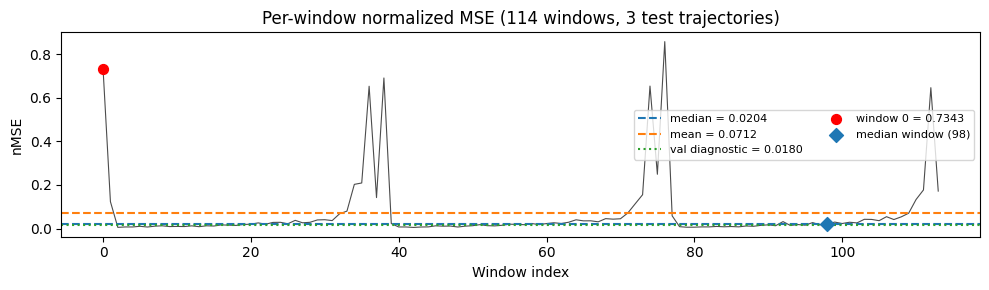

In [25]:
# ---- Plot per-window nMSE distribution ----
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(all_per_window_nmse, 'k-', lw=0.8, alpha=0.7)
ax.axhline(np.median(all_per_window_nmse), color='C0', ls='--', lw=1.5,
           label=f'median = {np.median(all_per_window_nmse):.4f}')
ax.axhline(all_per_window_nmse.mean(), color='C1', ls='--', lw=1.5,
           label=f'mean = {all_per_window_nmse.mean():.4f}')
ax.axhline(result.best_metrics.trajectory_val_loss, color='C2', ls=':', lw=1.5,
           label=f'val diagnostic = {result.best_metrics.trajectory_val_loss:.4f}')

# Mark window 0 and the median window
median_idx = np.argsort(all_per_window_nmse)[len(all_per_window_nmse) // 2]
ax.scatter([0], [all_per_window_nmse[0]], c='red', s=50, zorder=5, label=f'window 0 = {all_per_window_nmse[0]:.4f}')
ax.scatter([median_idx], [all_per_window_nmse[median_idx]], c='C0', s=50, zorder=5,
           marker='D', label=f'median window ({median_idx})')

ax.set_xlabel('Window index')
ax.set_ylabel('nMSE')
ax.set_title(f'Per-window normalized MSE ({len(all_per_window_nmse)} windows, {N_TEST_TRAJS} test trajectories)')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

Plotting median-loss window: index=98, nMSE=0.020737
(Compare to window 0 nMSE=0.734316)


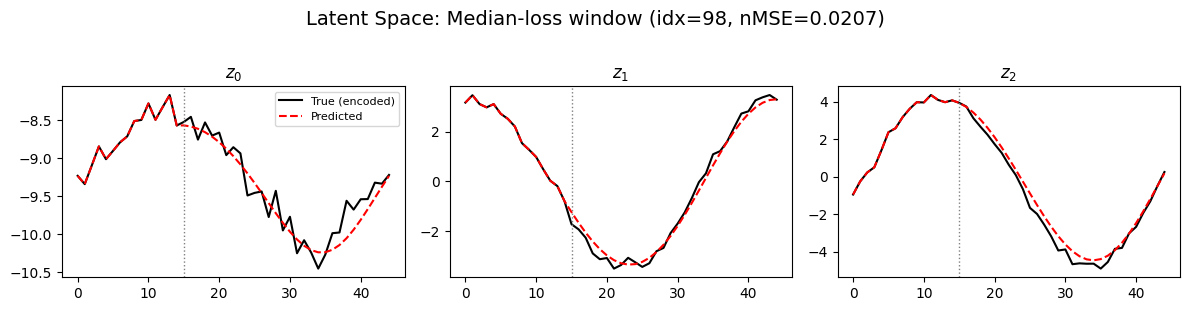

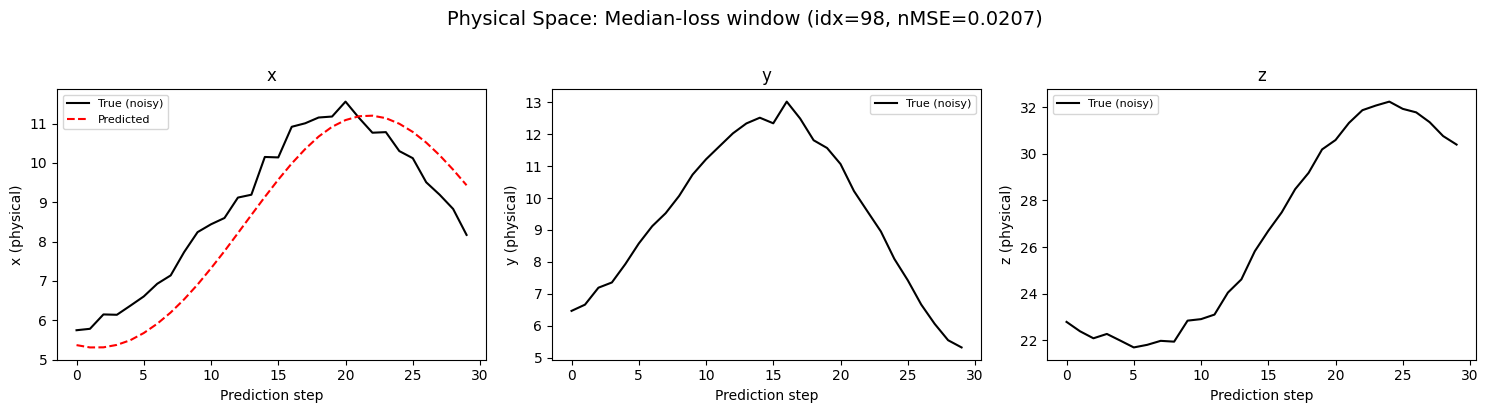

In [26]:
# ---- Representative (median-loss) window: latent + physical space ----
median_idx = int(np.argsort(all_per_window_nmse)[len(all_per_window_nmse) // 2])
print(f"Plotting median-loss window: index={median_idx}, nMSE={all_per_window_nmse[median_idx]:.6f}")
print(f"(Compare to window 0 nMSE={all_per_window_nmse[0]:.6f})")

z_pred_med = all_z_pred[median_idx]                # (jac_window_len, D_lat)
z_true_med = all_z_true_windows[median_idx]         # (jac_window_len, D_lat)
obs_pred_med = all_decoded_pred[median_idx]          # (pred_steps, D_obs)
obs_true_med = all_obs_targets[median_idx]            # (pred_steps, D_obs)

# ---- Latent space ----
n_latent = z_pred_med.shape[-1]
n_cols = min(5, n_latent)
n_rows = (n_latent + n_cols - 1) // n_cols
t_steps = np.arange(jac_window_len)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), squeeze=False)
for i in range(n_latent):
    ax = axes[i // n_cols, i % n_cols]
    ax.plot(t_steps, z_true_med[:, i], 'k-', lw=1.5, label='True (encoded)')
    ax.plot(t_steps, z_pred_med[:, i], 'r--', lw=1.5, label='Predicted')
    ax.axvline(x=traj_init_steps, color='gray', ls=':', lw=1)
    ax.set_title(f'$z_{{{i}}}$')
    if i == 0:
        ax.legend(fontsize=8)
for i in range(n_latent, n_rows * n_cols):
    axes[i // n_cols, i % n_cols].set_visible(False)
fig.suptitle(f'Latent Space: Median-loss window (idx={median_idx}, nMSE={all_per_window_nmse[median_idx]:.4f})',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ---- Physical space ----
t_pred = np.arange(obs_pred_med.shape[0])
dim_labels = ['x', 'y', 'z']

if OBSERVED_INDICES != "all" and N_DELAYS > 1:
    obs_pred_phys_med = obs_pred_med[:, 0] * sigma + mu
    obs_true_phys_med = obs_true_med[:, 0] * sigma + mu

    # Find which test trajectory and local window this median_idx belongs to
    # (windows are concatenated across trajectories)
    T_prime = trajs['test_trajs'].sequence.shape[1]
    n_win_per_traj = max(1, (T_prime - jac_window_len) // stride + 1)
    traj_idx_med = median_idx // n_win_per_traj
    local_win_med = median_idx % n_win_per_traj

    delay_offset = (N_DELAYS - 1) * DELAY_SPACING
    margin = getattr(best_lit_model.encoder, 'context_margin', 0)
    win_start = local_win_med * stride
    pred_start_raw = margin + win_start + traj_init_steps + delay_offset
    pred_end_raw = pred_start_raw + best_lit_model.prediction_steps

    test_traj_full = np.asarray(trajs['test_trajs_full'].sequence)
    true_full_seg = test_traj_full[traj_idx_med, pred_start_raw:pred_end_raw] * sigma + mu

    n_full = true_full_seg.shape[-1]
    fig, axes_phys = plt.subplots(1, n_full, figsize=(5 * n_full, 4), squeeze=False)
    for d in range(n_full):
        ax = axes_phys[0, d]
        ax.plot(t_pred, true_full_seg[:, d], 'k-', lw=1.5, label='True (noisy)')
        if d == OBSERVED_INDICES[0]:
            ax.plot(t_pred, obs_pred_phys_med, 'r--', lw=1.5, label='Predicted')
        ax.set_xlabel('Prediction step')
        ax.set_ylabel(f'{dim_labels[d]} (physical)')
        ax.set_title(f'{dim_labels[d]}')
        ax.legend(fontsize=8)
    fig.suptitle(f'Physical Space: Median-loss window (idx={median_idx}, nMSE={all_per_window_nmse[median_idx]:.4f})',
                 fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    obs_pred_phys_med = obs_pred_med * sigma + mu
    obs_true_phys_med = obs_true_med * sigma + mu
    D_obs = obs_pred_med.shape[-1]
    fig, axes_phys = plt.subplots(1, D_obs, figsize=(5 * D_obs, 4), squeeze=False)
    for d in range(D_obs):
        ax = axes_phys[0, d]
        label = dim_labels[d] if d < len(dim_labels) else f'dim {d}'
        ax.plot(t_pred, obs_true_phys_med[:, d], 'k-', lw=1.5, label='True')
        ax.plot(t_pred, obs_pred_phys_med[:, d], 'r--', lw=1.5, label='Predicted')
        ax.set_xlabel('Prediction step'); ax.set_ylabel(f'{label} (physical)'); ax.set_title(label)
        ax.legend(fontsize=8)
    fig.suptitle(f'Physical Space: Median-loss window (nMSE={all_per_window_nmse[median_idx]:.4f})',
                 fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

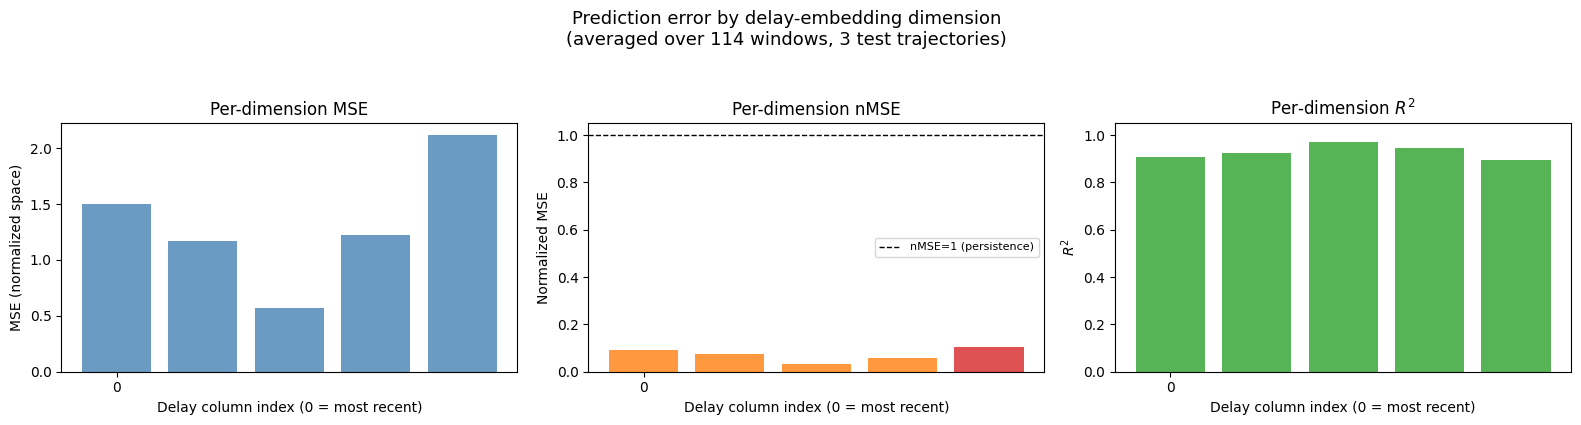

 Dim    Lag (dt)         MSE        nMSE          R²   Var(true)
--------------------------------------------------------------
   0      0.0000    1.498680    0.093152      0.9068   16.088516
   1      0.1502    1.173035    0.074017      0.9260   15.848193
   2      0.3004    0.572266    0.031203      0.9688   18.340275
   3      0.4506    1.222645    0.056716      0.9433   21.557226
   4      0.6008    2.117553    0.103422      0.8966   20.474859

Overall nMSE (mean across dims): 0.071702
Dim 0 (current x) nMSE:          0.093152
Dim 42 (oldest delay) nMSE:       0.103422


In [27]:
# ---- Per-dimension MSE across the 43 delay-embedded columns ----
# Columns: dim 0 = x(t) (most recent), dim 1 = x(t - delay_spacing), ..., dim 42 = x(t - 42*delay_spacing)
# This shows how prediction error changes with delay history depth.

# MSE per dimension, averaged across all windows and prediction steps
# all_decoded_pred: (total_windows, pred_steps, D_obs=43)
# all_obs_targets:  (total_windows, pred_steps, D_obs=43)
per_dim_mse = ((all_decoded_pred - all_obs_targets) ** 2).mean(axis=(0, 1))  # (D_obs,)
per_dim_var = all_obs_targets.reshape(-1, all_obs_targets.shape[-1]).var(axis=0)  # (D_obs,)
per_dim_nmse = per_dim_mse / np.clip(per_dim_var, 1e-8, None)

# Also compute per-dimension R^2
per_dim_r2 = 1.0 - per_dim_nmse

# X-axis: delay index → physical time lag
delay_lags = np.arange(all_obs_targets.shape[-1]) * DELAY_SPACING * dt  # in time units

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Panel 1: Raw MSE per dimension
ax = axes[0]
ax.bar(range(len(per_dim_mse)), per_dim_mse, color='steelblue', alpha=0.8)
ax.set_xlabel('Delay column index (0 = most recent)')
ax.set_ylabel('MSE (normalized space)')
ax.set_title('Per-dimension MSE')
ax.set_xticks(range(0, len(per_dim_mse), 5))

# Panel 2: Normalized MSE per dimension
ax = axes[1]
colors = ['C3' if v > 0.1 else 'C1' if v > 0.01 else 'C0' for v in per_dim_nmse]
ax.bar(range(len(per_dim_nmse)), per_dim_nmse, color=colors, alpha=0.8)
ax.axhline(1.0, color='k', ls='--', lw=1, label='nMSE=1 (persistence)')
ax.set_xlabel('Delay column index (0 = most recent)')
ax.set_ylabel('Normalized MSE')
ax.set_title('Per-dimension nMSE')
ax.set_xticks(range(0, len(per_dim_nmse), 5))
ax.legend(fontsize=8)

# Panel 3: R^2 per dimension
ax = axes[2]
ax.bar(range(len(per_dim_r2)), per_dim_r2, color='C2', alpha=0.8)
ax.axhline(0.0, color='k', ls='--', lw=0.5)
ax.set_xlabel('Delay column index (0 = most recent)')
ax.set_ylabel('$R^2$')
ax.set_title('Per-dimension $R^2$')
ax.set_xticks(range(0, len(per_dim_r2), 5))
ax.set_ylim(min(0, per_dim_r2.min() - 0.05), 1.05)

fig.suptitle(
    f'Prediction error by delay-embedding dimension\n'
    f'(averaged over {len(all_per_window_nmse)} windows, {N_TEST_TRAJS} test trajectories)',
    fontsize=13, y=1.05,
)
plt.tight_layout()
plt.show()

# Summary table
print(f"{'Dim':>4s}  {'Lag (dt)':>10s}  {'MSE':>10s}  {'nMSE':>10s}  {'R²':>10s}  {'Var(true)':>10s}")
print("-" * 62)
for d in range(len(per_dim_mse)):
    lag_str = f"{d * DELAY_SPACING * dt:.4f}"
    print(f"{d:4d}  {lag_str:>10s}  {per_dim_mse[d]:10.6f}  {per_dim_nmse[d]:10.6f}  {per_dim_r2[d]:10.4f}  {per_dim_var[d]:10.6f}")

print(f"\nOverall nMSE (mean across dims): {per_dim_nmse.mean():.6f}")
print(f"Dim 0 (current x) nMSE:          {per_dim_nmse[0]:.6f}")
print(f"Dim 42 (oldest delay) nMSE:       {per_dim_nmse[-1]:.6f}")

## 12. Export PDF Report

Collects all key results (config summary, model selection, Lyapunov spectrum,
latent space analysis, prediction diagnostics) into a single PDF.

In [28]:
import math
from datetime import datetime
from matplotlib.backends.backend_pdf import PdfPages

# ---- Derive a descriptive filename ----
data_cls = cfg.data.flow._target_.split(".")[-1]
enc_type = type(best_lit_model.encoder).__name__
n_latent = best_lit_model.encoder.n_latent
freeze_tag = "frozen" if not any(p.requires_grad for p in best_lit_model.encoder.parameters()) else "unfrozen"
date_str = datetime.now().strftime("%Y-%m-%d")
pdf_name = f"{date_str}_{data_cls}_{enc_type}_n{n_latent}_{freeze_tag}_lambda{best_lambda}.pdf"
pdf_path = os.path.join(os.getcwd(), pdf_name)

print(f"Exporting report to: {pdf_path}")

with PdfPages(pdf_path) as pdf:

    # ==================================================================
    # Page 1: Config summary + model selection
    # ==================================================================
    fig, ax = plt.subplots(figsize=(11, 8.5))
    ax.axis("off")

    lines = [
        f"Pretrained Encoder + JacobianODE — Report",
        f"{'=' * 60}",
        f"Date: {date_str}",
        f"W&B project: {WANDB_PROJECT_PATH}",
        f"Best run ID: {best_run_id}  (lambda={best_lambda})",
        f"",
        f"DATA",
        f"  System: {data_cls}",
        f"  dt = {dt:.4f}",
        f"  Observed indices: {OBSERVED_INDICES}",
        f"  N_delays = {N_DELAYS}, delay_spacing = {DELAY_SPACING}",
        f"  n_obs (delay-embedded) = {n_obs}",
        f"  Obs noise = {cfg.data.postprocessing.obs_noise}",
        f"  Num ICs = {cfg.data.trajectory_params.num_ics}, N_periods = {cfg.data.trajectory_params.n_periods}",
        f"",
        f"ENCODER",
        f"  Type: {enc_type}",
        f"  n_latent = {n_latent}",
        f"  Frozen: {freeze_tag}",
        f"  Encoder params: {sum(p.numel() for p in best_lit_model.encoder.parameters()):,}",
        f"",
        f"JACOBIAN ODE",
        f"  prediction_steps = {best_lit_model.prediction_steps}",
        f"  traj_init_steps = {best_lit_model.jacobianODEint_kwargs.get('traj_init_steps', 15)}",
        f"  Jac MLP params: {sum(p.numel() for p in best_lit_model.model.parameters()):,}",
        f"  Total params: {sum(p.numel() for p in best_lit_model.parameters()):,}",
        f"",
        f"MODEL SELECTION",
        f"  Sweep lambdas: {sweep_lambdas}",
        f"  Criteria applied: {result.criteria_applied}",
        f"  Surviving: {len(result.surviving_indices)} / {len(all_diagnostics)}",
        f"  Best traj val loss: {result.best_metrics.trajectory_val_loss:.6f}",
        f"  Best MASE: {result.best_metrics.one_step_mase:.4f}",
        f"  Best loop closure: {result.best_metrics.loop_closure_loss:.4f}",
    ]
    ax.text(0.05, 0.95, "\n".join(lines), transform=ax.transAxes,
            fontsize=9, verticalalignment="top", fontfamily="monospace")
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # ==================================================================
    # Page 2: Model selection bar charts
    # ==================================================================
    fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))

    one_step_mases = [m.one_step_mase for m in all_diagnostics]
    loop_closure_losses = [m.loop_closure_loss for m in all_diagnostics]
    eig_fracs = [m.fast_eigenvalue_fraction for m in all_diagnostics]
    traj_losses = [m.trajectory_val_loss for m in all_diagnostics]

    colors = ["tab:green" if i in result.surviving_indices else "tab:red"
              for i in range(len(all_diagnostics))]
    x_labels = [str(v) for v in sweep_lambdas]
    x_pos = range(len(sweep_lambdas))

    axes[0, 0].bar(x_pos, one_step_mases, color=colors)
    if result.best_index is not None:
        axes[0, 0].bar(result.best_index, one_step_mases[result.best_index],
                       color="gold", edgecolor="black", linewidth=2)
    axes[0, 0].axhline(y=1.0, color="k", linestyle="--", lw=1)
    axes[0, 0].set_xticks(x_pos); axes[0, 0].set_xticklabels(x_labels, rotation=45, ha="right")
    axes[0, 0].set_ylabel("MASE"); axes[0, 0].set_title("C1: One-step MASE")

    axes[0, 1].bar(x_pos, loop_closure_losses, color=colors)
    if result.best_index is not None:
        axes[0, 1].bar(result.best_index, loop_closure_losses[result.best_index],
                       color="gold", edgecolor="black", linewidth=2)
    axes[0, 1].set_xticks(x_pos); axes[0, 1].set_xticklabels(x_labels, rotation=45, ha="right")
    axes[0, 1].set_ylabel("Loop closure loss"); axes[0, 1].set_title("C2: Loop Closure")

    axes[1, 0].bar(x_pos, eig_fracs, color=colors)
    if result.best_index is not None:
        axes[1, 0].bar(result.best_index, eig_fracs[result.best_index],
                       color="gold", edgecolor="black", linewidth=2)
    axes[1, 0].set_xticks(x_pos); axes[1, 0].set_xticklabels(x_labels, rotation=45, ha="right")
    axes[1, 0].set_ylabel("Fraction fast eigs"); axes[1, 0].set_title("C3: Eigenvalue Spectrum")

    axes[1, 1].bar(x_pos, traj_losses, color=colors)
    if result.best_index is not None:
        axes[1, 1].bar(result.best_index, traj_losses[result.best_index],
                       color="gold", edgecolor="black", linewidth=2)
    axes[1, 1].set_xticks(x_pos); axes[1, 1].set_xticklabels(x_labels, rotation=45, ha="right")
    axes[1, 1].set_ylabel("Traj val loss"); axes[1, 1].set_title("Trajectory Validation Loss")

    fig.suptitle(f"Model Selection (best lambda={best_lambda})", fontsize=13)
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # ==================================================================
    # Page 3: Lyapunov spectrum
    # ==================================================================
    fig, ax = plt.subplots(figsize=(11, 5))
    pred_np = pred_lyap.numpy()
    ax.bar(np.arange(len(pred_np)) - 0.15, pred_np, width=0.3, label="Predicted", alpha=0.8)
    ax.bar(np.arange(len(TRUE_LYAPUNOV)) + 0.15, TRUE_LYAPUNOV, width=0.3, label="True", alpha=0.8)
    ax.axhline(y=0, color="k", linestyle="--", lw=0.5)
    ax.set_xlabel("Exponent index")
    ax.set_ylabel("Lyapunov exponent")
    ax.set_title(f"Lyapunov Spectrum (best lambda={best_lambda})")
    ax.legend()
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # Add a text summary of Lyapunov exponents
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.axis("off")
    lyap_lines = ["Predicted Lyapunov exponents (best model):"]
    for i, le in enumerate(pred_np):
        lyap_lines.append(f"  lambda_{i+1} = {le:+.4f}")
    lyap_lines.append("")
    lyap_lines.append(f"True {data_cls}:")
    for i, le in enumerate(TRUE_LYAPUNOV):
        lyap_lines.append(f"  lambda_{i+1} = {le:+.4f}")
    lyap_lines.append("")
    lyap_lines.append(f"MSE (top {len(TRUE_LYAPUNOV)} exponents): "
                      f"{np.mean((pred_np[:len(TRUE_LYAPUNOV)] - np.array(TRUE_LYAPUNOV))**2):.4f}")
    ax.text(0.05, 0.95, "\n".join(lyap_lines), transform=ax.transAxes,
            fontsize=11, verticalalignment="top", fontfamily="monospace")
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # ==================================================================
    # Page 4: Latent space analysis
    # ==================================================================
    # Per-dimension variance
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    dim_var = Z_flat.var(axis=0)
    axes[0].bar(range(len(dim_var)), dim_var / dim_var.sum(), color="steelblue")
    axes[0].set_xlabel("Latent dimension")
    axes[0].set_ylabel("Fractional variance")
    axes[0].set_title("Latent dimension utilisation")

    p = dim_var / dim_var.sum()
    entropy = -np.sum(p * np.log(p + 1e-10))
    util = entropy / math.log(n_latent)

    axes[1].text(0.1, 0.7, f"Utilization: {util:.3f}\nParticipation ratio: {pr_latent:.3f}\n"
                 f"True state PR: {pr_true:.3f}",
                 transform=axes[1].transAxes, fontsize=12, fontfamily="monospace")
    axes[1].axis("off")
    axes[1].set_title("Summary")
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # PCA embedding plots
    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    axes[0].scatter(Z_pc[:, 0], Z_pc[:, 1], s=1, alpha=0.3, c=Z_pc[:, 0], cmap="viridis")
    axes[0].set_xlabel("PC 1"); axes[0].set_ylabel("PC 2")
    axes[0].set_title(f"Latents (PR={pr_latent:.3f})")
    axes[1].scatter(X_true_pc[:, 0], X_true_pc[:, 1], s=1, alpha=0.3, c=X_true_pc[:, 0], cmap="viridis")
    axes[1].set_xlabel("PC 1"); axes[1].set_ylabel("PC 2")
    axes[1].set_title(f"True state (PR={pr_true:.3f})")
    fig.suptitle("PC 1 x PC 2", fontsize=12)
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # ==================================================================
    # Page 5: Per-window nMSE distribution
    # ==================================================================
    all_per_window_nmse_arr = np.array(all_per_window_nmse)
    fig, ax = plt.subplots(figsize=(11, 3.5))
    ax.plot(all_per_window_nmse_arr, "k-", lw=0.8, alpha=0.7)
    ax.axhline(np.median(all_per_window_nmse_arr), color="C0", ls="--", lw=1.5,
               label=f"median = {np.median(all_per_window_nmse_arr):.4f}")
    ax.axhline(all_per_window_nmse_arr.mean(), color="C1", ls="--", lw=1.5,
               label=f"mean = {all_per_window_nmse_arr.mean():.4f}")
    median_idx_pdf = int(np.argsort(all_per_window_nmse_arr)[len(all_per_window_nmse_arr) // 2])
    ax.scatter([median_idx_pdf], [all_per_window_nmse_arr[median_idx_pdf]], c="C0", s=50,
               zorder=5, marker="D", label=f"median window ({median_idx_pdf})")
    ax.set_xlabel("Window index")
    ax.set_ylabel("nMSE")
    ax.set_title(f"Per-window nMSE ({len(all_per_window_nmse_arr)} windows)")
    ax.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # ==================================================================
    # Page 6: Median-loss window — latent space
    # ==================================================================
    z_pred_med = all_z_pred[median_idx]
    z_true_med = all_z_true_windows[median_idx]
    obs_pred_med = all_decoded_pred[median_idx]
    obs_true_med = all_obs_targets[median_idx]

    n_lat = z_pred_med.shape[-1]
    n_cols_lat = min(5, n_lat)
    n_rows_lat = (n_lat + n_cols_lat - 1) // n_cols_lat
    t_steps = np.arange(jac_window_len)

    fig, axes = plt.subplots(n_rows_lat, n_cols_lat,
                             figsize=(4 * n_cols_lat, 3 * n_rows_lat), squeeze=False)
    for i in range(n_lat):
        ax = axes[i // n_cols_lat, i % n_cols_lat]
        ax.plot(t_steps, z_true_med[:, i], "k-", lw=1.5, label="True (encoded)")
        ax.plot(t_steps, z_pred_med[:, i], "r--", lw=1.5, label="Predicted")
        ax.axvline(x=traj_init_steps, color="gray", ls=":", lw=1)
        ax.set_title(f"$z_{{{i}}}$")
        if i == 0:
            ax.legend(fontsize=8)
    for i in range(n_lat, n_rows_lat * n_cols_lat):
        axes[i // n_cols_lat, i % n_cols_lat].set_visible(False)
    fig.suptitle(f"Latent Space: Median-loss window (idx={median_idx}, "
                 f"nMSE={all_per_window_nmse[median_idx]:.4f})", fontsize=13, y=1.02)
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # ==================================================================
    # Page 7: Median-loss window — physical space
    # ==================================================================
    t_pred = np.arange(obs_pred_med.shape[0])
    dim_labels = ["x", "y", "z"]

    if OBSERVED_INDICES != "all" and N_DELAYS > 1:
        obs_pred_phys = obs_pred_med[:, 0] * sigma + mu
        obs_true_phys = obs_true_med[:, 0] * sigma + mu

        # Find which test trajectory and local window this belongs to
        T_prime = trajs["test_trajs"].sequence.shape[1]
        margin = getattr(best_lit_model.encoder, "context_margin", 0)
        T_latent = T_prime - margin
        n_win_per_traj = max(1, (T_latent - jac_window_len) // stride + 1)
        traj_idx = median_idx // n_win_per_traj
        local_win = median_idx % n_win_per_traj
        obs_start = local_win * stride + traj_init_steps + margin

        full_obs = trajs.get("test_trajs_full")
        if full_obs is not None:
            full_state = np.asarray(full_obs.sequence)
            true_full = full_state[traj_idx, obs_start:obs_start + best_lit_model.prediction_steps]
        else:
            true_full = None

        n_phys = true_full.shape[-1] if true_full is not None else 1
        fig, axes_phys = plt.subplots(1, n_phys, figsize=(5 * n_phys, 4), squeeze=False)
        for d in range(n_phys):
            ax = axes_phys[0, d]
            lbl = dim_labels[d] if d < len(dim_labels) else f"dim {d}"
            if true_full is not None:
                ax.plot(t_pred[:len(true_full)], true_full[:, d], "k-", lw=1.5, label="True (noisy)")
            if d == 0:
                ax.plot(t_pred, obs_pred_phys, "r--", lw=1.5, label="Predicted")
            ax.set_xlabel("Prediction step")
            ax.set_ylabel(f"{lbl} (physical)")
            ax.set_title(lbl)
            ax.legend(fontsize=8)
        fig.suptitle(f"Physical Space: Median-loss window (idx={median_idx}, "
                     f"nMSE={all_per_window_nmse[median_idx]:.4f})", fontsize=13, y=1.02)
        plt.tight_layout()
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

    # ==================================================================
    # Page 8: Per-dimension prediction error
    # ==================================================================
    per_dim_mse_r = ((all_decoded_pred - all_obs_targets) ** 2).mean(axis=(0, 1))
    per_dim_var_r = all_obs_targets.reshape(-1, all_obs_targets.shape[-1]).var(axis=0)
    per_dim_nmse_r = per_dim_mse_r / np.clip(per_dim_var_r, 1e-8, None)
    per_dim_r2_r = 1.0 - per_dim_nmse_r

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].bar(range(len(per_dim_mse_r)), per_dim_mse_r, color="steelblue", alpha=0.8)
    axes[0].set_xlabel("Delay column index (0 = most recent)")
    axes[0].set_ylabel("MSE (normalized space)")
    axes[0].set_title("Per-dimension MSE")

    colors_nmse = ["C3" if v > 0.1 else "C1" if v > 0.01 else "C0" for v in per_dim_nmse_r]
    axes[1].bar(range(len(per_dim_nmse_r)), per_dim_nmse_r, color=colors_nmse, alpha=0.8)
    axes[1].axhline(1.0, color="k", ls="--", lw=1, label="nMSE=1 (persistence)")
    axes[1].set_xlabel("Delay column index (0 = most recent)")
    axes[1].set_ylabel("Normalized MSE")
    axes[1].set_title("Per-dimension nMSE")
    axes[1].legend(fontsize=8)

    axes[2].bar(range(len(per_dim_r2_r)), per_dim_r2_r, color="C2", alpha=0.8)
    axes[2].axhline(0.0, color="k", ls="--", lw=0.5)
    axes[2].set_xlabel("Delay column index (0 = most recent)")
    axes[2].set_ylabel("$R^2$")
    axes[2].set_title("Per-dimension $R^2$")

    fig.suptitle(f"Prediction error by delay-embedding dimension\n"
                 f"(averaged over {len(all_per_window_nmse)} windows, {N_TEST_TRAJS} test trajectories)",
                 fontsize=12)
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # ==================================================================
    # Page 9: Per-dimension summary table
    # ==================================================================
    fig, ax = plt.subplots(figsize=(11, 6))
    ax.axis("off")
    delay_lags_r = np.arange(all_obs_targets.shape[-1]) * DELAY_SPACING * dt
    header = f"{'Dim':>5s}  {'Lag (dt)':>12s}  {'MSE':>12s}  {'nMSE':>12s}  {'R²':>12s}  {'Var(true)':>12s}"
    sep = "-" * len(header)
    table_lines = [header, sep]
    for d in range(len(per_dim_mse_r)):
        table_lines.append(
            f"{d:5d}  {delay_lags_r[d]:12.4f}  {per_dim_mse_r[d]:12.6f}  "
            f"{per_dim_nmse_r[d]:12.6f}  {per_dim_r2_r[d]:12.4f}  {per_dim_var_r[d]:12.6f}"
        )
    table_lines.append("")
    table_lines.append(f"Overall nMSE (mean across dims): {per_dim_nmse_r.mean():.6f}")
    table_lines.append(f"Dim 0 (current x) nMSE:          {per_dim_nmse_r[0]:.6f}")
    if len(per_dim_nmse_r) > 1:
        table_lines.append(f"Dim {len(per_dim_nmse_r)-1} (oldest delay) nMSE:       "
                           f"{per_dim_nmse_r[-1]:.6f}")
    ax.text(0.02, 0.98, "\n".join(table_lines), transform=ax.transAxes,
            fontsize=7, verticalalignment="top", fontfamily="monospace")
    ax.set_title("Per-dimension prediction error table", fontsize=12)
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

print(f"\nReport saved to: {pdf_path}")
print(f"Pages: 9")

Exporting report to: /orcd/home/002/eisenaj/code/JacobianODE/_jupyter/2026-03-07_Lorenz_EigentimeDelayAdapter_n3_frozen_lambda1e-06.pdf

Report saved to: /orcd/home/002/eisenaj/code/JacobianODE/_jupyter/2026-03-07_Lorenz_EigentimeDelayAdapter_n3_frozen_lambda1e-06.pdf
Pages: 9


## PCA Encode/Decode Diagnostic

Verify that the ETD adapter's PCA round-trip (encode then decode) preserves
the signal. If reconstruction error is large, the 6-component PCA is too lossy
and observation-space metrics will suffer even with perfect latent predictions.

PCA round-trip: 5D -> 3D -> 5D
Overall reconstruction: MSE=5.517175, nMSE=0.089427, R²=0.910573

Per-dimension R² (first 10 / last 5):
  dim  0: R²=0.396851  nMSE=0.603149
  dim  1: R²=0.909718  nMSE=0.090282
  dim  2: R²=0.960917  nMSE=0.039083
  dim  3: R²=0.912891  nMSE=0.087109
  dim  4: R²=0.901219  nMSE=0.098781
  ...
  dim  0: R²=0.396851  nMSE=0.603149
  dim  1: R²=0.909718  nMSE=0.090282
  dim  2: R²=0.960917  nMSE=0.039083
  dim  3: R²=0.912891  nMSE=0.087109
  dim  4: R²=0.901219  nMSE=0.098781


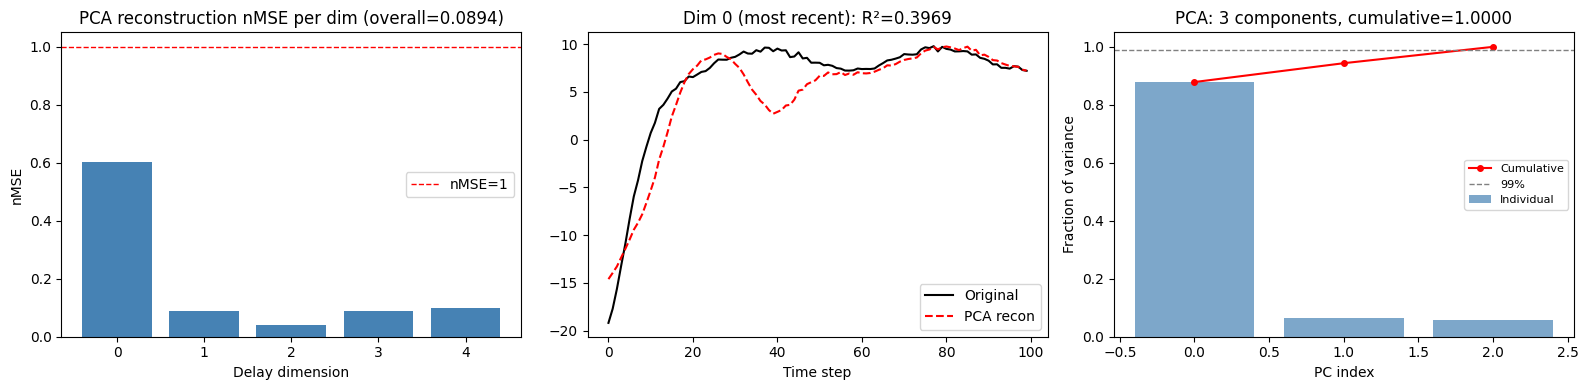


MASE floor (PCA recon, same windows as model): 2.1813
  Computed over 640 windows from 20 val batches
  This is the best possible obs-space MASE with 3 PCA components.

Model's actual MASE per lambda: ['1.8799', '1.8801', '1.8807', '1.8824', '1.8889', '1.8936', '2.1390', '2.1399', '2.1399', '2.1401']

This suggests the model MASE and floor MASE are computed differently.
Check: compute_all_diagnostics uses trajectory_model_step with alpha_teacher_forcing=1
which includes JacobianODE integration, not just decode(encode(x)).


In [29]:
# ---- PCA round-trip diagnostic ----
adapter = best_lit_model.encoder
device = next(best_lit_model.parameters()).device

# Grab a test batch
test_batch = next(iter(test_dl))
if isinstance(test_batch, (list, tuple)):
    test_batch = test_batch[0]
x = test_batch.to(device).float()  # (B, T, 43)

with torch.no_grad():
    z = adapter.encode(x)           # (B, T, 6)
    x_recon = adapter.decode(z)     # (B, T, 43)

x_np = x.cpu().numpy()
x_recon_np = x_recon.cpu().numpy()
z_np = z.cpu().numpy()

# Per-dimension reconstruction error
mse_per_dim = ((x_np - x_recon_np) ** 2).mean(axis=(0, 1))
var_per_dim = x_np.reshape(-1, x_np.shape[-1]).var(axis=0)
nmse_per_dim = mse_per_dim / np.clip(var_per_dim, 1e-8, None)
r2_per_dim = 1.0 - nmse_per_dim

overall_mse = ((x_np - x_recon_np) ** 2).mean()
overall_var = x_np.var()
overall_nmse = overall_mse / overall_var

print(f"PCA round-trip: {x_np.shape[-1]}D -> {z_np.shape[-1]}D -> {x_recon_np.shape[-1]}D")
print(f"Overall reconstruction: MSE={overall_mse:.6f}, nMSE={overall_nmse:.6f}, R\u00b2={1-overall_nmse:.6f}")
print(f"\nPer-dimension R\u00b2 (first 10 / last 5):")
for i in range(min(10, len(r2_per_dim))):
    print(f"  dim {i:2d}: R\u00b2={r2_per_dim[i]:.6f}  nMSE={nmse_per_dim[i]:.6f}")
print("  ...")
for i in range(max(0, len(r2_per_dim)-5), len(r2_per_dim)):
    print(f"  dim {i:2d}: R\u00b2={r2_per_dim[i]:.6f}  nMSE={nmse_per_dim[i]:.6f}")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].bar(range(len(nmse_per_dim)), nmse_per_dim, color='steelblue')
axes[0].set_xlabel("Delay dimension")
axes[0].set_ylabel("nMSE")
axes[0].set_title(f"PCA reconstruction nMSE per dim (overall={overall_nmse:.4f})")
axes[0].axhline(1.0, color='r', ls='--', lw=1, label='nMSE=1')
axes[0].legend()

traj_idx = 0
axes[1].plot(x_np[traj_idx, :, 0], 'k-', lw=1.5, label='Original')
axes[1].plot(x_recon_np[traj_idx, :, 0], 'r--', lw=1.5, label='PCA recon')
axes[1].set_xlabel("Time step")
axes[1].set_title(f"Dim 0 (most recent): R\u00b2={r2_per_dim[0]:.4f}")
axes[1].legend()

S = adapter._singular_values.cpu().numpy()
var_explained = S**2 / (S**2).sum()
cumvar = np.cumsum(var_explained)
axes[2].bar(range(len(S)), var_explained, color='steelblue', alpha=0.7, label='Individual')
axes[2].plot(range(len(S)), cumvar, 'ro-', ms=4, label='Cumulative')
axes[2].axhline(0.99, color='gray', ls='--', lw=1, label='99%')
axes[2].set_xlabel("PC index")
axes[2].set_ylabel("Fraction of variance")
axes[2].set_title(f"PCA: {len(S)} components, cumulative={cumvar[-1]:.4f}")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

# ---- MASE floor: computed the SAME way as compute_all_diagnostics ----
# The actual mase() function (3D case):
#   numerator:   mean(|y_true - y_pred|)
#   denominator: mean(|y_true[:, 1:] - y_true[:, :-1]|)
#
# With perfect latent predictions, y_pred = decode(encode(y_true)).
# We compute this over the SAME prediction windows the model uses.
from JacobianODE.jacobians.metrics import mase as mase_fn

best_lit_model.eval()
traj_init_steps = best_lit_model.jacobianODEint_kwargs.get('traj_init_steps', 15)
pred_steps = best_lit_model.prediction_steps
jac_window_len = traj_init_steps + pred_steps
margin = getattr(adapter, 'context_margin', 0)
stride = best_lit_model.jac_window_stride

mase_floors = []
with torch.no_grad():
    for i, batch in enumerate(val_dl):
        if i >= 20:
            break
        batch_t = batch[0].to(device).float() if isinstance(batch, (list, tuple)) else batch.to(device).float()
        B, T, D = batch_t.shape
        z_enc = adapter.encode(batch_t)
        x_recon_batch = adapter.decode(z_enc)
        if margin > 0:
            x_recon_batch = x_recon_batch[:, margin:, :]
            label = batch_t[:, margin:, :]
        else:
            label = batch_t
        T_eff = label.shape[1]
        n_windows = max(1, (T_eff - jac_window_len) // stride + 1)
        for b in range(B):
            for w_idx in range(n_windows):
                start = w_idx * stride
                end = start + jac_window_len
                if end > T_eff:
                    continue
                obs_true_win = label[b, start + traj_init_steps:end]
                obs_recon_win = x_recon_batch[b, start + traj_init_steps:end]
                m = mase_fn(obs_true_win, obs_recon_win)
                mase_floors.append(m.item())

mase_floor = np.mean(mase_floors)
print(f"\nMASE floor (PCA recon, same windows as model): {mase_floor:.4f}")
print(f"  Computed over {len(mase_floors)} windows from 20 val batches")
print(f"  This is the best possible obs-space MASE with {z_np.shape[-1]} PCA components.")
print(f"\nModel's actual MASE per lambda: {[f'{m.one_step_mase:.4f}' for m in all_diagnostics]}")

# If floor > model MASE, something is wrong with how MASE is computed
if any(m.one_step_mase < mase_floor * 0.9 for m in all_diagnostics):
    print("\nWARNING: Some model MASEs are below the PCA floor!")
    print("This suggests the model MASE and floor MASE are computed differently.")
    print("Check: compute_all_diagnostics uses trajectory_model_step with alpha_teacher_forcing=1")
    print("which includes JacobianODE integration, not just decode(encode(x)).")
